### Keras: Erste Versuche

#### 1) Daten laden

In [ ]:
import pandas as pd
from math import ceil

pd.set_option('display.max_columns', 6)

data_url=r'https://raw.githubusercontent.com/rawe64/ai/main/ndx100.csv'
df = pd.read_csv(data_url)
df.head()

,m199,m99,m49,...,m3,m1,p5
0,-34.023668,-24.908597,-26.302555,...,-3.567182,0.328812,-5.638866
1,-45.493319,-34.786439,-31.315602,...,-10.180812,-5.099538,-6.134486
2,-42.415836,-36.541864,-34.279911,...,-4.975005,-0.211015,-6.591711
3,-53.283988,-36.786283,-40.070083,...,-9.990068,-4.432868,-6.060527
4,-40.239003,-34.040967,-29.901523,...,1.331406,5.718546,-9.906045


#### 2) x-/y-Daten selektieren und standardisieren

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[['m199', 'm99','m49','m19','m9','m5','m3','m1']].values
y = df[['p5']].values

scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y)

X.shape, y.shape

((6185, 8), (6185, 1))

#### 3) Keras-Modell aufbauen

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input # Import Input layer

# Good practice: Start with an Input layer
model = Sequential([
    Input(shape=(8,)), # Explicitly define input shape
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary() # This will work immediately and show all layers and shapes

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

#### 4) Modell kompilieren


In [ ]:
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import SGD

mse = MeanSquaredError()
sgd = SGD(learning_rate=0.005)
model.compile(loss=mse, optimizer=sgd)

#### 5) Modell anlernen

In [ ]:
history = model.fit(X, y, epochs=50, batch_size=16)

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0508
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0102
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9890
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0189
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0089
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0117
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0106
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0084
Epoch 9/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0216
Epoch 10/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0276
Epoch 11/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0112
Epoch 12/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9763
Epoch 13/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9944
Epoch 14/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9916
Epoch 15/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

#### 6) Nach dem Anlernen

##### Gewichte abfragen:

In [ ]:
weights = model.get_layer(index=0).get_weights()
weights

[array([[-0.07792013, -0.09405755,  0.09116159, -0.42548522,  0.5847503 ,
         -0.19234605, -0.13006084, -0.16734836],
        [-0.6510556 , -0.12909664,  0.46134025, -0.1100211 , -0.3796116 ,
         -0.50553936,  0.29196694, -0.3110527 ],
        [ 0.25300103,  0.28000897,  0.4048187 ,  0.6172171 , -0.36116838,
          0.4991724 , -0.04163823,  0.29727802],
        [ 0.27373192, -0.24507256, -0.3675293 ,  0.20322597,  0.24836323,
         -0.491484  , -0.26220268, -0.10193972],
        [ 0.14528567,  0.16475515, -0.35926023, -0.351976  ,  0.19091812,
          0.21553932,  0.01550953,  0.35889372],
        [ 0.49741998,  0.01443132,  0.24273236, -0.16700804, -0.18778309,
         -0.05557412, -0.19945458, -0.27857998],
        [-0.4992659 , -0.40294018,  0.10830346, -0.39704236, -0.46996126,
          0.59951836,  0.49263182, -0.2844466 ],
        [-0.11738142, -0.33008417,  0.6349511 , -0.3231175 , -0.17784065,
         -0.14526916, -0.26981834,  0.51681656]], dtype=float32),

##### Schätzungen für einen Beispieldatensatz erzeugen:

In [ ]:
X_pred = [[13.4281648769462,2.03529417147459,16.0717962326652,4.30356464726417,0.267199846268572,1.03082406445738,0.627736625137835,1.05187062769086]]
X_pred = scaler_X.transform(X_pred)
y_pred = model.predict(X_pred)
y_pred = scaler_y.inverse_transform(y_pred)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


array([[-0.15786365]], dtype=float32)

#### 7) Evaluation

##### R-Quadrat:

In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print('r2 = {:.3f}'.format(r2))

194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
r2 = 0.009


#### 8) Anlernprozess graphisch darstellen

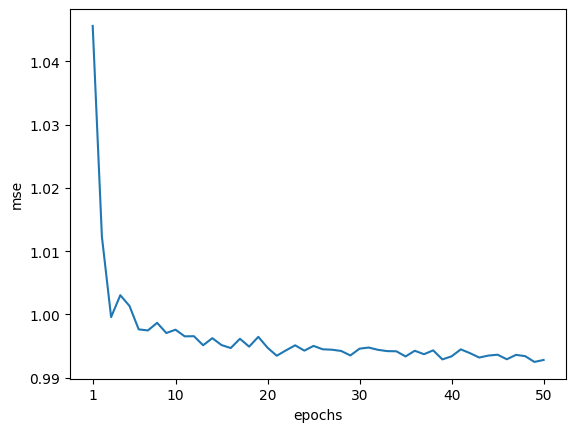

In [ ]:
import matplotlib.pyplot as plt

loss_mse = history.history['loss']
plt.xticks([1,10,20,30,40,50])
plt.ylabel('mse')
plt.xlabel('epochs')
plt.plot(range(1, len(loss_mse)+1), loss_mse)